<a href="https://colab.research.google.com/github/OJB-Quantum/Qiskit-Metal-to-Litho/blob/main/6_Xmon_Layout_in_3D_using_K3D_and_Quantum_Metal_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [1]:
# @title Clone Qiskit Metal; Headless Setup
"""Setup script for Qiskit Metal in a headless Google Colab environment.

This script configures the environment for headless operation, installs
scientific dependencies without breaking torch, and patches Qiskit Metal
to remove GUI dependencies (PySide2).
"""

import logging
import os
import re
import sys
import textwrap
from pathlib import Path

# -----------------------------------------------------------------------------
# 1. Environment Configuration
# -----------------------------------------------------------------------------
# Must be set before importing matplotlib or any GUI-related libs
os.environ["QT_QPA_PLATFORM"] = "offscreen"
os.environ["MPLBACKEND"] = "Agg"

import matplotlib as mpl
try:
    mpl.use("Agg", force=True)
except TypeError:
    mpl.use("Agg")

# Constants
REPO_URL = "https://github.com/qiskit-community/qiskit-metal"
ROOT_DIR = Path("/content/qiskit-metal")
SRC_DIR = ROOT_DIR / "src"
PKG_DIR = SRC_DIR / "qiskit_metal"

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


# -----------------------------------------------------------------------------
# 2. Dependency Installation
# -----------------------------------------------------------------------------
def install_dependencies():
    """Installs required scientific and GDS toolchain.

    Avoids '--upgrade setuptools' to prevent conflicts with pre-installed
    torch versions in Google Colab.
    """
    logger.info("Installing dependencies...")
    # Upgrade pip and wheel, but leave setuptools to avoid torch conflicts
    %pip -q install --upgrade pip wheel

    # Install toolchain
    # We use a list for readability and to avoid long single-line strings
    packages = [
        "numpy>=1.24", "matplotlib>=3.8", "gdstk>=0.9.61",
        "shapely>=2.0", "ezdxf>=1.2.0", "pandas>=2.0",
        "scipy>=1.10", "networkx>=2.8", "pint>=0.20",
        "addict>=2.4.0", "pyyaml>=6.0.1", "qutip>=4.7",
        "h5py>=3.8", "descartes>=1.1", "jedi>=0.19.1"
    ]
    %pip -q install {" ".join(packages)}
    logger.info("Dependencies installed successfully.")


# -----------------------------------------------------------------------------
# 3. Repository Management
# -----------------------------------------------------------------------------
def setup_repository():
    """Clones the Qiskit Metal repository and verifies the structure.

    Returns:
        Path: The path to the package directory.

    Raises:
        RuntimeError: If the package directory is not found after cloning.
    """
    logger.info("Cleaning old installation and cloning repository...")
    !rm -rf {ROOT_DIR}
    !git clone --depth 1 {REPO_URL} {ROOT_DIR}

    if not PKG_DIR.exists():
        logger.error("Package folder not found at %s", PKG_DIR)
        if ROOT_DIR.exists():
            logger.info("Root directory contents: %s", os.listdir(ROOT_DIR))
        raise RuntimeError(
            f"Git clone failed to provide the qiskit_metal package folder "
            f"at {PKG_DIR}."
        )

    return PKG_DIR


def configure_python_path():
    """Configures sys.path and PYTHONPATH to include the src directory."""
    if str(SRC_DIR) not in sys.path:
        sys.path.insert(0, str(SRC_DIR))

    current_pythonpath = os.environ.get("PYTHONPATH", "")
    os.environ["PYTHONPATH"] = f"{SRC_DIR}:{current_pythonpath}"
    logger.info("Python path configured to include %s", SRC_DIR)


def patch_package_init():
    """Replaces the package __init__.py with a minimal headless version."""
    init_file = PKG_DIR / "__init__.py"
    if not init_file.exists():
        return

    # Backup original
    orig_init = init_file.read_text(encoding="utf-8")
    (PKG_DIR / "__init__orig.py").write_text(orig_init, encoding="utf-8")

    minimal_init = textwrap.dedent("""
        # [colab] Headless, layout-only __init__
        import logging as _logging
        try:
            from addict import Dict as Dict
        except Exception:
            try:
                from .toolbox_python.attr_dict import Dict
            except Exception:
                class Dict(dict): pass

        logger = _logging.getLogger("qiskit_metal_colab")

        class _Config:
            @staticmethod
            def is_building_docs():
                return False
        config = _Config()

        def is_design(obj):
            try:
                from .designs.design_base import QDesign
                return isinstance(obj, QDesign)
            except Exception:
                return False

        def is_component(obj):
            try:
                from .qlibrary.core.base import QComponent
                return isinstance(obj, QComponent)
            except Exception:
                return False

        __all__ = ["Dict", "config", "logger", "is_design", "is_component"]
    """).strip() + "\n"

    init_file.write_text(minimal_init, encoding="utf-8")
    logger.info("Patched %s for headless mode.", init_file)


def scrub_draw_imports():
    """Removes PySide2/Qt dependencies from the draw module initialization."""
    draw_init = PKG_DIR / "draw" / "__init__.py"
    if not draw_init.exists():
        return

    content = draw_init.read_text(encoding="utf-8")

    # Guard "from . import mpl"
    content = re.sub(
        r'^\s*from\s+\.\s*import\s+mpl\s*$',
        "try:\n    from . import mpl\n"
        "except Exception as _e:\n"
        "    print('[colab] draw.mpl disabled (headless):', _e)\n",
        content,
        flags=re.MULTILINE,
    )

    # Guard "from .mpl import ..."
    content = re.sub(
        r'^\s*from\s+\.\s*mpl\s+import[^\n]*$',
        "try:\n    from .mpl import render, figure_spawn\n"
        "except Exception as _e:\n"
        "    print('[colab] draw.mpl (named) disabled (headless):', _e)\n"
        "    def render(*a, **k):\n"
        "        raise RuntimeError('draw.mpl unavailable in headless mode')\n"
        "    def figure_spawn(*a, **k):\n"
        "        raise RuntimeError('draw.mpl unavailable in headless mode')\n",
        content,
        flags=re.MULTILINE,
    )

    draw_init.write_text(content, encoding="utf-8")
    logger.info("Scrubbed Qt imports from %s", draw_init)


def disable_renderers():
    """Disables the renderers package to prevent Qt imports."""
    rndr_init = PKG_DIR / "renderers" / "__init__.py"
    if rndr_init.exists():
        # Backup
        (rndr_init.parent / "__init__orig.py").write_text(
            rndr_init.read_text(encoding="utf-8"), encoding="utf-8"
        )
        # Override
        rndr_init.write_text(
            "# [colab] minimal renderers package\n__all__ = []\n",
            encoding="utf-8",
        )
        logger.info("Disabled renderers package at %s", rndr_init)


# -----------------------------------------------------------------------------
# 4. Main Execution
# -----------------------------------------------------------------------------
def main():
    """Main execution flow for Qiskit Metal setup."""
    try:
        install_dependencies()
        setup_repository()
        configure_python_path()
        patch_package_init()
        scrub_draw_imports()
        disable_renderers()

        # Final Verification
        import importlib
        importlib.invalidate_caches()

        import qiskit_metal
        print(f"Success! qiskit_metal imported from: {qiskit_metal.__file__}")
        print(f"Matplotlib backend: {mpl.get_backend()}")

    except Exception as e:
        logger.error("Setup failed: %s", e)
        raise


if __name__ == "__main__":
    main()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 20.3 MB/s eta 0:00:00
Cloning into '/content/qiskit-metal'...
remote: Enumerating objects: 1191, done.
remote: Counting objects: 100% (1191/1191), done.
remote: Compressing objects: 100% (1034/1034), done.
remote: Total 1191 (delta 171), reused 940 (delta 145), pack-reused 0 (from 0)
Receiving objects: 100% (1191/1191), 36.13 MiB | 34.97 MiB/s, done.
Resolving deltas: 100% (171/171), done.
Success! qiskit_metal imported from: /content/qiskit-metal/src/qiskit_metal/__init__.py
Matplotlib backend: Agg


In [2]:
!apt-get -qq update && apt-get -qq install -y openmpi-bin libopenmpi-dev
!pip install -q "k3d==2.18.1" trimesh "cupy-cuda12x>=13.0,<14" ipywidgets

# Enable Colab widget support.
from google.colab import output
output.enable_custom_widget_manager()

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


Creating DesignPlanar with enable_renderers=False.
Exporting Quantum Metal qgeometry through a fillet preserving GDSTK path.

Six qubit resonator plan


,qubit,x,y,qubit_orientation,clt_orientation,target_frequency_ghz,route_total_length,meander_asymmetry
0,Q1_L,-1700um,1500um,-90,-90,6.116,4905.167um,-90um
1,Q2_L,-1700um,0um,-90,-90,6.353,4722.178um,90um
2,Q3_L,-1700um,-1500um,-90,-90,6.472,4635.352um,-90um
3,Q1_R,1700um,1500um,90,90,6.568,4567.600um,90um
4,Q2_R,1700um,0um,90,90,6.655,4507.889um,-90um
5,Q3_R,1700um,-1500um,90,90,6.704,4474.940um,90um



Component pin audit


,component,class,pins
0,Q1_L,TransmonCross,c
1,Q1_R,TransmonCross,c
2,Q2_L,TransmonCross,c
3,Q2_R,TransmonCross,c
4,Q3_L,TransmonCross,c
5,Q3_R,TransmonCross,c
6,clt_Q1_L,CoupledLineTee,"prime_start,prime_end,second_end"
7,clt_Q1_R,CoupledLineTee,"prime_start,prime_end,second_end"
8,clt_Q2_L,CoupledLineTee,"prime_start,prime_end,second_end"
9,clt_Q2_R,CoupledLineTee,"prime_start,prime_end,second_end"



Wrote GDSTK GDS: /content/six_xmon_cheesing_quantum_metal.gds

Direct export summary


,layer,datatype,polygon_count,total_area_um2,min_vertices,max_vertices
0,3,0,33,7.179400e+05,4,532
1,3,1,228122,2.459648e+06,4,532
2,9,0,6,4.200000e+03,4,4



Fillet audit


,class,line_count,width_min_um,width_max_um,requested_fillet_max_um,used_fillet_min_um,used_fillet_max_um
0,CoupledLineTee,24,10.000,22.000,25.000,0.000,25.000
1,RouteMeander,12,10.000,22.000,70.000,70.000,70.000
2,RouteStraight,2,11.700,21.900,0.000,0.000,0.000
3,TransmonCross,6,35.000,35.000,70.000,0.000,0.000


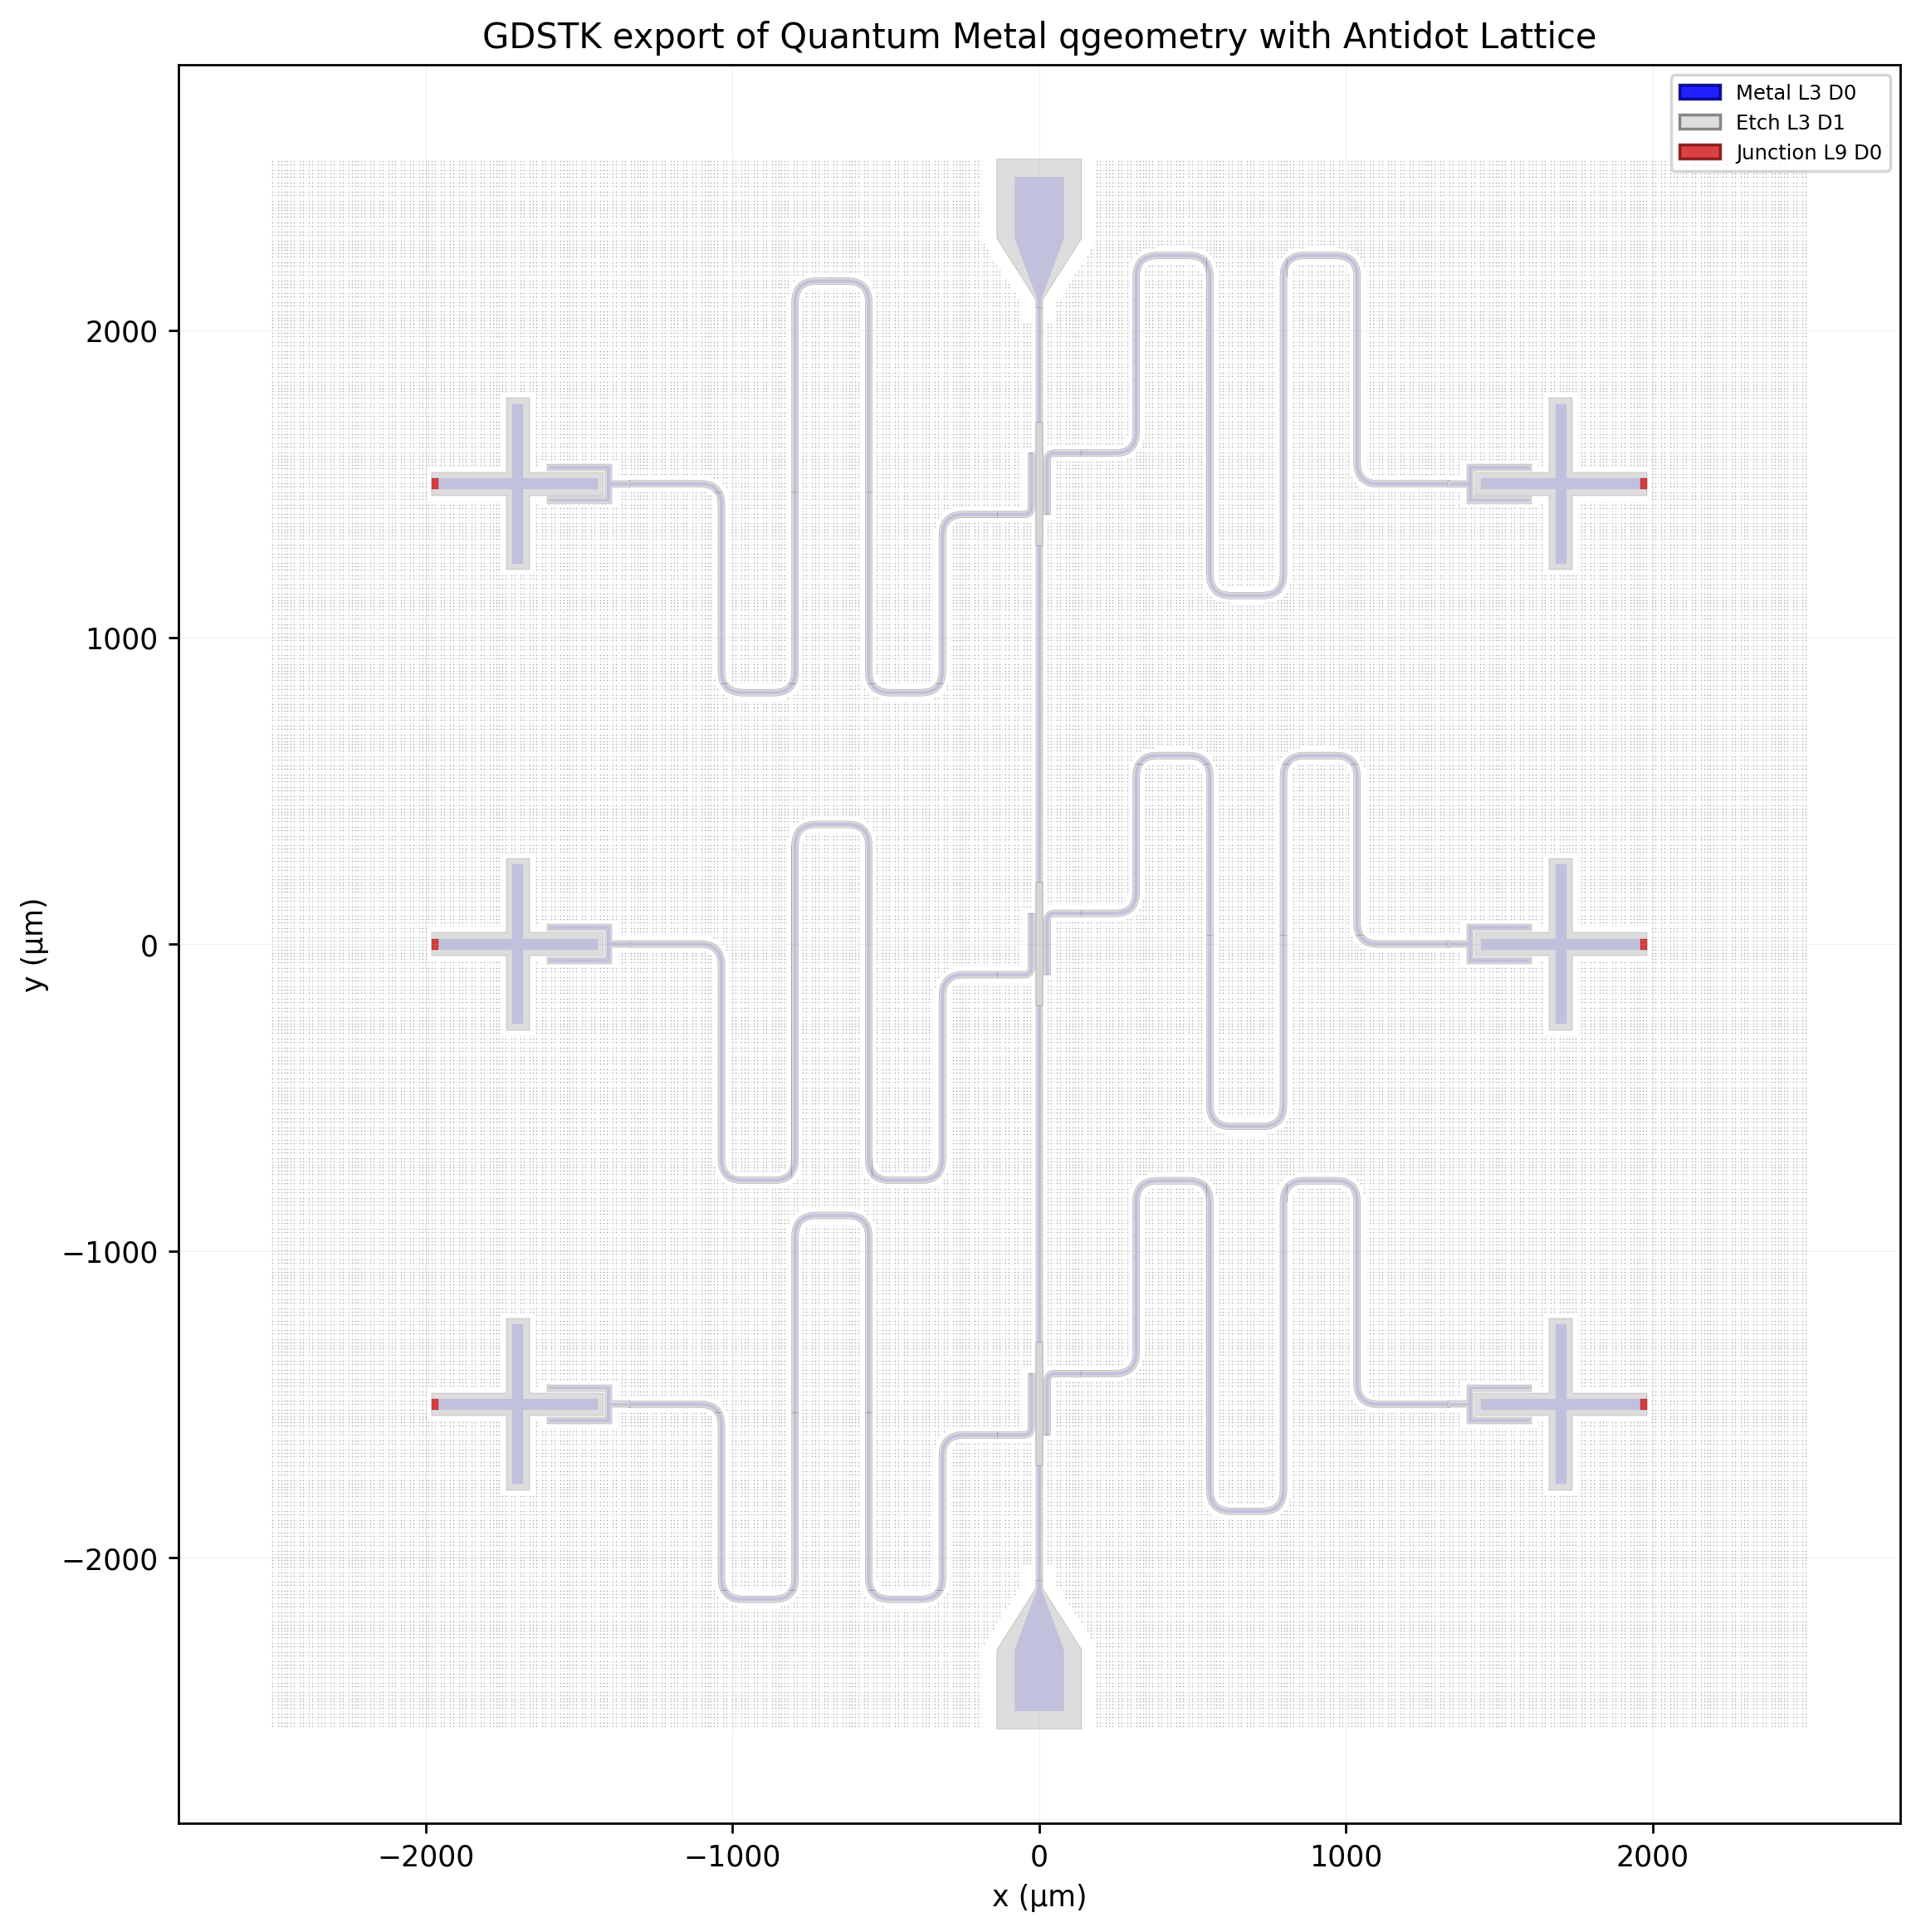

In [3]:
"""This script defines a six-qubit Quantum Metal layout.

This script uses Quantum Metal to generate component qgeometry,
then exports those qgeometry tables directly to GDS with GDSTK
while preserving microwave CPW fillets and generating an optimal
antidot lattice to prevent Abrikosov vortex mobility.
"""

import math
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Final

warnings.filterwarnings("ignore", category=SyntaxWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import gdstk
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.collections import PatchCollection
from matplotlib.patches import Patch
from matplotlib.patches import Polygon as MplPolygon
from shapely.geometry import GeometryCollection
from shapely.geometry import LineString
from shapely.geometry import MultiLineString
from shapely.geometry import MultiPolygon
from shapely.geometry import Polygon
from shapely.ops import transform

from qiskit_metal import Dict, designs
from qiskit_metal.qlibrary.couplers.coupled_line_tee import CoupledLineTee
from qiskit_metal.qlibrary.qubits.transmon_cross import TransmonCross
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.straight_path import RouteStraight

# =============================================================================
# CONTROL KNOBS
# =============================================================================

OUTPUT_GDS_PATH: Final[Path] = Path(
    "/content/six_xmon_cheesing_quantum_metal.gds"
)

WRITE_GDS: Final[bool] = True
RENDER_GDS: Final[bool] = True
SHOW_QGEOMETRY_SUMMARY: Final[bool] = True
SHOW_COMPONENT_PIN_AUDIT: Final[bool] = True
SHOW_FILLET_AUDIT: Final[bool] = True

# Antidot Lattice Generation Controls
ENABLE_ANTIDOTS: Final[bool] = True
ANTIDOT_PITCH_UM: Final[float] = 10.0
ANTIDOT_SIZE_UM: Final[float] = 2.0
ANTIDOT_OFFSET_X_UM: Final[float] = 9.0
ANTIDOT_OFFSET_Y_UM: Final[float] = 0.0
ANTIDOT_EXTENSION_Y_UM: Final[float] = 60.0
ANTIDOT_KEEPOUT_UM: Final[float] = 15.0
LAUNCHPAD_KEEPOUT_UM: Final[float] = 45.0

MPL_DPI: Final[int] = 250
FIGURE_WIDTH_IN: Final[float] = 11.0
FIGURE_HEIGHT_IN: Final[float] = 11.0

CHIP_SIZE_X: Final[str] = "5mm"
CHIP_SIZE_Y: Final[str] = "5mm"

# Quantum Metal qgeometry coordinates are conventionally in millimeters.
# Exporting to GDSTK with this scale writes coordinates in micrometers.
COORD_SCALE_TO_UM: Final[float] = 1000.0
GDS_UNIT_M: Final[float] = 1.0e-6
GDS_PRECISION_M: Final[float] = 1.0e-9

METAL_LAYER: Final[int] = 3
SUBTRACT_DATATYPE: Final[int] = 1
NORMAL_DATATYPE: Final[int] = 0
JUNCTION_LAYER: Final[int] = 9

TARGET_RESONATOR_FREQUENCIES_GHZ: Final[tuple[float, ...]] = (
    6.116,
    6.353,
    6.472,
    6.568,
    6.655,
    6.704,
)

CPW_PHASE_VELOCITY_M_PER_S: Final[float] = 1.20e8

FEEDLINE_TRACE_WIDTH: Final[str] = "11.7um"
FEEDLINE_TRACE_GAP: Final[str] = "5.1um"

ROUTE_TRACE_WIDTH: Final[str] = "10um"
ROUTE_TRACE_GAP: Final[str] = "6um"

# This is the Quantum Metal RouteMeander fillet request. The export code below
# clamps it if short local segments cannot support the requested radius.
RESONATOR_FILLET: Final[str] = "70um"
RESONATOR_MEANDER_SPACING: Final[str] = "240um"
RESONATOR_LEAD_START: Final[str] = "180um"
RESONATOR_LEAD_END: Final[str] = "140um"

DEFAULT_CROSS_LENGTH: Final[str] = "260um"
DEFAULT_CROSS_WIDTH: Final[str] = "35um"
DEFAULT_CROSS_GAP: Final[str] = "20um"

DEFAULT_CLAW_LENGTH: Final[str] = "190um"
DEFAULT_CLAW_WIDTH: Final[str] = "10um"
DEFAULT_CLAW_GAP: Final[str] = "6um"
DEFAULT_GROUND_SPACING: Final[str] = "5um"
DEFAULT_CLAW_CPW_LENGTH: Final[str] = "60um"
DEFAULT_CLAW_CPW_WIDTH: Final[str] = ROUTE_TRACE_WIDTH

DEFAULT_LJ_NH: Final[float] = 15.903982052718824
DEFAULT_COUPLING_LENGTH: Final[str] = "200um"
DEFAULT_COUPLING_SPACE: Final[str] = "4um"
DEFAULT_DOWN_LENGTH: Final[str] = "110um"

# Fillet reconstruction controls.
DEFAULT_ROUTE_FILLET_UM: Final[float] = 70.0
DEFAULT_COUPLER_FILLET_UM: Final[float] = 25.0
MIN_FILLET_RADIUS_UM: Final[float] = 8.0
FILLET_SAFETY_FRACTION: Final[float] = 0.42
SAMPLES_PER_FILLET: Final[int] = 18
BUFFER_RESOLUTION: Final[int] = 24

# Rendering styles. Normal geometry and subtract/cut geometry are shown with
# separate datatypes so KLayout and Matplotlib can distinguish them.
LAYER_STYLE_MAP: Final[dict[tuple[int, int], dict[str, str]]] = {
    (3, 0): {"facecolor": "#0000FF", "edgecolor": "#000080", "label": "Metal"},
    (3, 1): {"facecolor": "#D9D9D9", "edgecolor": "#777777", "label": "Etch"},
    (9, 0): {"facecolor": "#D62728", "edgecolor": "#7F1010", "label": "Junction"},
}

DEFAULT_STYLE: Final[dict[str, str]] = {
    "facecolor": "#A0A0A0",
    "edgecolor": "#505050",
    "label": "Other",
}

QUBIT_SITES: Final[tuple[dict[str, Any], ...]] = (
    {
        "name": "Q1_L",
        "x": "-1700um",
        "y": "1500um",
        "qubit_orientation": "-90",
        "clt_orientation": "-90",
        "meander_asymmetry": "-90um",
    },
    {
        "name": "Q2_L",
        "x": "-1700um",
        "y": "0um",
        "qubit_orientation": "-90",
        "clt_orientation": "-90",
        "meander_asymmetry": "90um",
    },
    {
        "name": "Q3_L",
        "x": "-1700um",
        "y": "-1500um",
        "qubit_orientation": "-90",
        "clt_orientation": "-90",
        "meander_asymmetry": "-90um",
    },
    {
        "name": "Q1_R",
        "x": "1700um",
        "y": "1500um",
        "qubit_orientation": "90",
        "clt_orientation": "90",
        "meander_asymmetry": "90um",
    },
    {
        "name": "Q2_R",
        "x": "1700um",
        "y": "0um",
        "qubit_orientation": "90",
        "clt_orientation": "90",
        "meander_asymmetry": "-90um",
    },
    {
        "name": "Q3_R",
        "x": "1700um",
        "y": "-1500um",
        "qubit_orientation": "90",
        "clt_orientation": "90",
        "meander_asymmetry": "90um",
    },
)

# Enforce formal publishing parameters for scientific illustrations.
mpl.rcParams["font.sans-serif"] = ["Tahoma", "DejaVu Sans"]
mpl.rcParams["font.weight"] = "normal"
mpl.rcParams["figure.dpi"] = MPL_DPI

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass


# =============================================================================
# DATA STRUCTURES
# =============================================================================


@dataclass(frozen=True)
class ComponentHandles:
    """Created Quantum Metal component references."""

    wirebonds: list[Any]
    qubits: list[Any]
    tees: list[Any]
    resonators: list[Any]
    feedline: Any


# =============================================================================
# NUMERIC HELPERS
# =============================================================================


def quarter_wave_lengths_um(frequencies_ghz: tuple[float, ...]) -> np.ndarray:
    """Compute first-pass quarter-wave resonator lengths in micrometers."""
    frequencies = np.asarray(frequencies_ghz, dtype=np.float64)
    lengths_m = CPW_PHASE_VELOCITY_M_PER_S / (4.0 * frequencies * 1.0e9)
    return lengths_m * 1.0e6


def build_resonator_length_strings() -> list[str]:
    """Return Quantum Metal total_length strings."""
    lengths_um = quarter_wave_lengths_um(TARGET_RESONATOR_FREQUENCIES_GHZ)
    return [f"{length:.3f}um" for length in lengths_um]


# =============================================================================
# QUANTUM METAL BUILD
# =============================================================================


def create_design() -> Any:
    """Create a renderer-free planar design."""
    design = designs.DesignPlanar(
        overwrite_enabled=True,
        enable_renderers=False,
    )

    try:
        design.chips.main.size.size_x = CHIP_SIZE_X
        design.chips.main.size.size_y = CHIP_SIZE_Y
    except Exception:
        design._chips["main"]["size"]["size_x"] = CHIP_SIZE_X
        design._chips["main"]["size"]["size_y"] = CHIP_SIZE_Y

    design.variables["cpw_width"] = ROUTE_TRACE_WIDTH
    design.variables["cpw_gap"] = ROUTE_TRACE_GAP
    return design


def select_component_pin(
    component: Any,
    preferred: str,
    fallbacks: tuple[str, ...],
) -> str:
    """Return a valid pin name from a component."""
    pin_names = list(component.pins.keys())

    if preferred in pin_names:
        return preferred

    for candidate in fallbacks:
        if candidate in pin_names:
            return candidate

    raise ValueError(
        f"Could not find a usable pin on {component.name}. "
        f"Available pins are {pin_names}."
    )


def create_wirebond(
    design: Any,
    name: str,
    pos_y: str,
    orientation: str,
) -> Any:
    """Create a feedline wirebond launch pad."""
    return LaunchpadWirebond(
        design,
        name,
        options=Dict(
            pos_x="0um",
            pos_y=pos_y,
            orientation=orientation,
            trace_width=FEEDLINE_TRACE_WIDTH,
            trace_gap=FEEDLINE_TRACE_GAP,
            lead_length="25um",
            pad_width="160um",
            pad_height="200um",
            pad_gap="58um",
            taper_height="200um",
            layer=str(METAL_LAYER),
        ),
    )


def create_feedline(
    design: Any,
    top_launch: Any,
    bottom_launch: Any,
) -> Any:
    """Create the straight vertical CPW feedline."""
    top_pin = select_component_pin(top_launch, "tie", ("in", "out"))
    bottom_pin = select_component_pin(bottom_launch, "tie", ("in", "out"))

    return RouteStraight(
        design,
        "feedline",
        options=Dict(
            pin_inputs=Dict(
                start_pin=Dict(component=top_launch.name, pin=top_pin),
                end_pin=Dict(component=bottom_launch.name, pin=bottom_pin),
            ),
            trace_width=FEEDLINE_TRACE_WIDTH,
            trace_gap=FEEDLINE_TRACE_GAP,
            layer=str(METAL_LAYER),
        ),
    )


def create_qubit(
    design: Any,
    site: dict[str, Any],
) -> Any:
    """Create a cross qubit with a claw connector facing the feedline."""
    return TransmonCross(
        design,
        site["name"],
        options=Dict(
            connection_pads=Dict(
                c=Dict(
                    connector_location="90",
                    connector_type="0",
                    claw_length=DEFAULT_CLAW_LENGTH,
                    claw_gap=DEFAULT_CLAW_GAP,
                    claw_width=DEFAULT_CLAW_WIDTH,
                    claw_cpw_length=DEFAULT_CLAW_CPW_LENGTH,
                    claw_cpw_width=DEFAULT_CLAW_CPW_WIDTH,
                    ground_spacing=DEFAULT_GROUND_SPACING,
                )
            ),
            cross_length=DEFAULT_CROSS_LENGTH,
            cross_width=DEFAULT_CROSS_WIDTH,
            cross_gap=DEFAULT_CROSS_GAP,
            pos_x=site["x"],
            pos_y=site["y"],
            orientation=site["qubit_orientation"],
            hfss_inductance=f"{DEFAULT_LJ_NH}nH",
            aedt_hfss_inductance=f"{DEFAULT_LJ_NH}nH",
            layer=str(METAL_LAYER),
        ),
    )


def create_coupled_line_tee(
    design: Any,
    site: dict[str, Any],
) -> Any:
    """Create the feedline-side hanger coupler."""
    return CoupledLineTee(
        design,
        f"clt_{site['name']}",
        options=Dict(
            pos_x="0um",
            pos_y=site["y"],
            orientation=site["clt_orientation"],
            prime_width=FEEDLINE_TRACE_WIDTH,
            prime_gap=FEEDLINE_TRACE_GAP,
            second_width=ROUTE_TRACE_WIDTH,
            second_gap=ROUTE_TRACE_GAP,
            coupling_space=DEFAULT_COUPLING_SPACE,
            coupling_length=DEFAULT_COUPLING_LENGTH,
            down_length=DEFAULT_DOWN_LENGTH,
            fillet="25um",
            open_termination=False,
            layer=str(METAL_LAYER),
        ),
    )


def select_tee_output_pin(tee: Any) -> str:
    """Return the output pin on the coupled-line tee."""
    pin_names = tuple(tee.pins.keys())

    for candidate in ("second_end", "second", "out", "prime_end"):
        if candidate in pin_names:
            return candidate

    for pin_name in pin_names:
        if "second" in pin_name:
            return pin_name

    raise ValueError(
        f"Could not find a tee output pin on {tee.name}. "
        f"Available pins are {list(pin_names)}."
    )


def create_readout_resonator(
    design: Any,
    site: dict[str, Any],
    tee: Any,
    qubit: Any,
    total_length: str,
) -> Any:
    """Create a meander from CLT output to the qubit claw pin."""
    tee_pin = select_tee_output_pin(tee)
    qubit_pin = select_component_pin(qubit, "c", tuple(qubit.pins.keys()))

    return RouteMeander(
        design,
        f"rr_{site['name']}",
        options=Dict(
            pin_inputs=Dict(
                start_pin=Dict(component=tee.name, pin=tee_pin),
                end_pin=Dict(component=qubit.name, pin=qubit_pin),
            ),
            lead=Dict(
                start_straight=RESONATOR_LEAD_START,
                end_straight=RESONATOR_LEAD_END,
            ),
            fillet=RESONATOR_FILLET,
            total_length=total_length,
            trace_width=ROUTE_TRACE_WIDTH,
            trace_gap=ROUTE_TRACE_GAP,
            meander=Dict(
                spacing=RESONATOR_MEANDER_SPACING,
                asymmetry=site["meander_asymmetry"],
            ),
            prevent_short_edges="true",
            snap="true",
            layer=str(METAL_LAYER),
        ),
    )


def build_chip() -> tuple[Any, ComponentHandles, pd.DataFrame]:
    """Build the complete six-qubit chip without starting renderers."""
    design = create_design()

    top_launch = create_wirebond(
        design=design,
        name="wb_top",
        pos_y="2100um",
        orientation="-90",
    )
    bottom_launch = create_wirebond(
        design=design,
        name="wb_bottom",
        pos_y="-2100um",
        orientation="90",
    )
    feedline = create_feedline(design, top_launch, bottom_launch)

    target_lengths = build_resonator_length_strings()

    qubits: list[Any] = []
    tees: list[Any] = []
    resonators: list[Any] = []
    summary_records: list[dict[str, Any]] = []

    for index, site in enumerate(QUBIT_SITES):
        qubit = create_qubit(design, site)
        tee = create_coupled_line_tee(design, site)
        resonator = create_readout_resonator(
            design=design,
            site=site,
            tee=tee,
            qubit=qubit,
            total_length=target_lengths[index],
        )

        qubits.append(qubit)
        tees.append(tee)
        resonators.append(resonator)

        summary_records.append(
            {
                "qubit": site["name"],
                "x": site["x"],
                "y": site["y"],
                "qubit_orientation": site["qubit_orientation"],
                "clt_orientation": site["clt_orientation"],
                "target_frequency_ghz": TARGET_RESONATOR_FREQUENCIES_GHZ[index],
                "route_total_length": target_lengths[index],
                "meander_asymmetry": site["meander_asymmetry"],
            }
        )

    handles = ComponentHandles(
        wirebonds=[top_launch, bottom_launch],
        qubits=qubits,
        tees=tees,
        resonators=resonators,
        feedline=feedline,
    )
    summary = pd.DataFrame(summary_records)

    return design, handles, summary


# =============================================================================
# DIRECT QGEOMETRY TO FILLETED GDSTK EXPORT
# =============================================================================


def parse_bool(value: Any) -> bool:
    """Parse a possible bool-like qgeometry value."""
    if isinstance(value, bool):
        return value

    if isinstance(value, str):
        return value.strip().lower() in {"true", "1", "yes"}

    try:
        return bool(value)
    except Exception:
        return False


def parse_layer(value: Any, fallback: int = METAL_LAYER) -> int:
    """Parse a qgeometry layer value."""
    try:
        if pd.isna(value):
            return fallback
    except Exception:
        pass

    try:
        return int(value)
    except Exception:
        return fallback


def parse_value_mm(
    design: Any,
    value: Any,
    fallback_mm: float,
) -> float:
    """Parse a Quantum Metal value into millimeters."""
    if value is None:
        return fallback_mm

    try:
        if pd.isna(value):
            return fallback_mm
    except Exception:
        pass

    try:
        return float(design.parse_value(value))
    except Exception:
        pass

    try:
        return float(value)
    except Exception:
        return fallback_mm


def parse_value_um(
    design: Any,
    value: Any,
    fallback_um: float,
) -> float:
    """Parse a Quantum Metal value into micrometers."""
    value_mm = parse_value_mm(
        design=design,
        value=value,
        fallback_mm=fallback_um / COORD_SCALE_TO_UM,
    )
    return value_mm * COORD_SCALE_TO_UM


def component_lookup_by_id(design: Any) -> dict[int, Any]:
    """Map Quantum Metal component IDs to component objects."""
    lookup: dict[int, Any] = {}

    for component in design.components.values():
        component_id = getattr(component, "id", None)

        if component_id is None:
            component_id = getattr(component, "_id", None)

        if component_id is None:
            continue

        try:
            lookup[int(component_id)] = component
        except Exception:
            continue

    return lookup


def component_for_row(
    design: Any,
    row: pd.Series,
    lookup: dict[int, Any],
) -> Any | None:
    """Return the component associated with a qgeometry row."""
    component_value = row.get("component")

    try:
        return lookup.get(int(component_value))
    except Exception:
        pass

    if isinstance(component_value, str):
        try:
            return design.components[component_value]
        except Exception:
            return None

    return None


def get_option(component: Any | None, key: str) -> Any | None:
    """Read a component option if present."""
    if component is None:
        return None

    options = getattr(component, "options", None)
    if options is None:
        return None

    try:
        return options[key]
    except Exception:
        pass

    try:
        return options.get(key)
    except Exception:
        return None


def trace_width_um(
    design: Any,
    row: pd.Series,
    component: Any | None,
) -> float:
    """Return the trace width for a LineString row."""
    row_width = row.get("width")

    if row_width is not None:
        return parse_value_um(
            design=design,
            value=row_width,
            fallback_um=10.0,
        )

    for key in ("trace_width", "second_width", "prime_width", "claw_width"):
        value = get_option(component, key)

        if value is not None:
            return parse_value_um(
                design=design,
                value=value,
                fallback_um=10.0,
            )

    return 10.0


def requested_fillet_um(
    design: Any,
    component: Any | None,
) -> float:
    """Return the intended microwave route fillet in micrometers."""
    class_name = component.__class__.__name__ if component is not None else ""

    option_value = get_option(component, "fillet")
    if option_value is not None:
        return parse_value_um(
            design=design,
            value=option_value,
            fallback_um=DEFAULT_ROUTE_FILLET_UM,
        )

    if "Route" in class_name:
        return DEFAULT_ROUTE_FILLET_UM

    if "CoupledLineTee" in class_name:
        return DEFAULT_COUPLER_FILLET_UM

    return 0.0


def scale_geometry_to_um(geometry: Any) -> Any:
    """Scale Shapely geometry from millimeters to micrometers."""
    return transform(
        lambda x_coord, y_coord, z_coord=None: (
            x_coord * COORD_SCALE_TO_UM,
            y_coord * COORD_SCALE_TO_UM,
        ),
        geometry,
    )


def clean_coords(coords: Any) -> np.ndarray:
    """Return polygon coordinates without duplicated closure."""
    points = np.asarray(coords, dtype=float)

    if len(points) >= 2 and np.allclose(points[0], points[-1]):
        points = points[:-1]

    return points


def clean_line_points(points: np.ndarray) -> np.ndarray:
    """Remove repeated consecutive centerline points."""
    cleaned: list[np.ndarray] = []

    for point in np.asarray(points, dtype=float):
        if len(cleaned) == 0:
            cleaned.append(point)
            continue

        if np.linalg.norm(point - cleaned[-1]) > 1.0e-9:
            cleaned.append(point)

    return np.asarray(cleaned, dtype=float)


def quadratic_bezier_points(
    start: np.ndarray,
    control: np.ndarray,
    end: np.ndarray,
    samples: int,
) -> np.ndarray:
    """Sample a quadratic Bezier fillet segment."""
    t_values = np.linspace(0.0, 1.0, samples + 2)
    return (
        ((1.0 - t_values) ** 2)[:, None] * start[None, :]
        + (2.0 * (1.0 - t_values) * t_values)[:, None] * control[None, :]
        + (t_values**2)[:, None] * end[None, :]
    )


def safe_corner_radius_um(
    points: np.ndarray,
    requested_radius_um: float,
) -> float:
    """Clamp the requested fillet radius to available segment lengths."""
    if points.shape[0] < 3 or requested_radius_um <= 0.0:
        return 0.0

    segment_lengths = np.linalg.norm(np.diff(points, axis=0), axis=1)
    if segment_lengths.shape[0] < 2:
        return 0.0

    adjacent_limits = [
        min(segment_lengths[index - 1], segment_lengths[index])
        for index in range(1, points.shape[0] - 1)
    ]

    if len(adjacent_limits) == 0:
        return 0.0

    allowed_radius = FILLET_SAFETY_FRACTION * min(adjacent_limits)
    radius = min(float(requested_radius_um), float(allowed_radius))

    if radius < MIN_FILLET_RADIUS_UM:
        return 0.0

    return radius


def rounded_centerline_um(
    line: LineString,
    requested_radius_um: float,
) -> tuple[np.ndarray, float]:
    """Return a rounded centerline sampled in micrometers and its radius."""
    raw_points = np.asarray(line.coords, dtype=float) * COORD_SCALE_TO_UM
    points = clean_line_points(raw_points)

    if points.shape[0] <= 2:
        return points, 0.0

    radius_um = safe_corner_radius_um(points, requested_radius_um)

    if radius_um <= 0.0:
        return points, 0.0

    output: list[np.ndarray] = [points[0]]

    for index in range(1, points.shape[0] - 1):
        previous_point = points[index - 1]
        corner_point = points[index]
        next_point = points[index + 1]

        incoming = corner_point - previous_point
        outgoing = next_point - corner_point

        incoming_length = float(np.linalg.norm(incoming))
        outgoing_length = float(np.linalg.norm(outgoing))

        if incoming_length <= 1.0e-12 or outgoing_length <= 1.0e-12:
            continue

        incoming_unit = incoming / incoming_length
        outgoing_unit = outgoing / outgoing_length

        cosine_angle = float(np.clip(np.dot(incoming_unit, outgoing_unit), -1.0, 1.0))
        deflection = math.acos(cosine_angle)

        if deflection <= 1.0e-9 or abs(math.pi - deflection) <= 1.0e-9:
            output.append(corner_point)
            continue

        trim_um = radius_um * math.tan(0.5 * deflection)
        trim_um = min(trim_um, 0.45 * incoming_length, 0.45 * outgoing_length)

        entry_point = corner_point - incoming_unit * trim_um
        exit_point = corner_point + outgoing_unit * trim_um

        if np.linalg.norm(output[-1] - entry_point) > 1.0e-9:
            output.append(entry_point)

        curve = quadratic_bezier_points(
            start=entry_point,
            control=corner_point,
            end=exit_point,
            samples=SAMPLES_PER_FILLET,
        )

        for curve_point in curve[1:]:
            output.append(curve_point)

    if np.linalg.norm(output[-1] - points[-1]) > 1.0e-9:
        output.append(points[-1])

    return np.asarray(output, dtype=float), radius_um


def line_to_rounded_polygon(
    line: LineString,
    width_um: float,
    requested_radius_um: float,
) -> tuple[Polygon, float]:
    """Convert a centerline into a rounded CPW trace polygon."""
    centerline, used_radius_um = rounded_centerline_um(
        line=line,
        requested_radius_um=requested_radius_um,
    )

    if centerline.shape[0] < 2:
        return Polygon(), used_radius_um

    trace = LineString(centerline).buffer(
        0.5 * width_um,
        cap_style=2,
        join_style=1,
        resolution=BUFFER_RESOLUTION,
    )
    return trace, used_radius_um


def polygon_to_gdstk(
    polygon: Polygon,
    layer: int,
    datatype: int,
) -> list[gdstk.Polygon]:
    """Convert a Shapely polygon, including holes, into GDSTK polygons."""
    if polygon.is_empty or polygon.area <= 0.0:
        return []

    outer = gdstk.Polygon(
        clean_coords(polygon.exterior.coords),
        layer=layer,
        datatype=datatype,
    )

    holes = [
        gdstk.Polygon(
            clean_coords(interior.coords),
            layer=layer,
            datatype=datatype,
        )
        for interior in polygon.interiors
    ]

    if len(holes) == 0:
        return [outer]

    return gdstk.boolean(
        [outer],
        holes,
        "not",
        precision=1.0e-3,
        layer=layer,
        datatype=datatype,
    )


def geometry_to_gdstk(
    geometry: Any,
    layer: int,
    datatype: int,
) -> list[gdstk.Polygon]:
    """Convert Shapely polygonal geometry into GDSTK polygons."""
    if geometry.is_empty:
        return []

    if isinstance(geometry, Polygon):
        return polygon_to_gdstk(geometry, layer, datatype)

    if isinstance(geometry, MultiPolygon):
        polygons: list[gdstk.Polygon] = []
        for polygon in geometry.geoms:
            polygons.extend(polygon_to_gdstk(polygon, layer, datatype))
        return polygons

    if isinstance(geometry, GeometryCollection):
        polygons: list[gdstk.Polygon] = []
        for item in geometry.geoms:
            polygons.extend(geometry_to_gdstk(item, layer, datatype))
        return polygons

    return []


def row_geometry_to_polygons(
    design: Any,
    table_name: str,
    row: pd.Series,
    lookup: dict[int, Any],
    fillet_records: list[dict[str, Any]],
) -> list[gdstk.Polygon]:
    """Convert one qgeometry row to one or more GDSTK polygons."""
    geometry = row.get("geometry")

    if geometry is None or geometry.is_empty:
        return []

    component = component_for_row(design, row, lookup)
    component_name = getattr(component, "name", "unknown")
    component_class = component.__class__.__name__ if component is not None else "unknown"

    layer = parse_layer(row.get("layer"), fallback=METAL_LAYER)
    subtract = parse_bool(row.get("subtract", False))
    datatype = SUBTRACT_DATATYPE if subtract else NORMAL_DATATYPE

    if table_name == "junction":
        layer = JUNCTION_LAYER
        datatype = NORMAL_DATATYPE

    if isinstance(geometry, LineString):
        width_um = trace_width_um(design, row, component)
        fillet_um = requested_fillet_um(design, component)
        rounded_geometry, used_radius = line_to_rounded_polygon(
            line=geometry,
            width_um=width_um,
            requested_radius_um=fillet_um,
        )

        fillet_records.append(
            {
                "table": table_name,
                "component": component_name,
                "class": component_class,
                "width_um": width_um,
                "requested_fillet_um": fillet_um,
                "used_fillet_um": used_radius,
            }
        )

        return geometry_to_gdstk(rounded_geometry, layer, datatype)

    if isinstance(geometry, MultiLineString):
        width_um = trace_width_um(design, row, component)
        fillet_um = requested_fillet_um(design, component)
        polygons: list[gdstk.Polygon] = []

        for line in geometry.geoms:
            rounded_geometry, used_radius = line_to_rounded_polygon(
                line=line,
                width_um=width_um,
                requested_radius_um=fillet_um,
            )
            polygons.extend(geometry_to_gdstk(rounded_geometry, layer, datatype))

            fillet_records.append(
                {
                    "table": table_name,
                    "component": component_name,
                    "class": component_class,
                    "width_um": width_um,
                    "requested_fillet_um": fillet_um,
                    "used_fillet_um": used_radius,
                }
            )

        return polygons

    scaled_geometry = scale_geometry_to_um(geometry)
    return geometry_to_gdstk(scaled_geometry, layer, datatype)


def export_qgeometry_to_gds(
    design: Any,
    output_path: Path,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Export Quantum Metal qgeometry tables through GDSTK with fillets and antidots."""
    library = gdstk.Library(unit=GDS_UNIT_M, precision=GDS_PRECISION_M)
    top_cell = library.new_cell("TOP")

    all_polygons: list[gdstk.Polygon] = []
    export_records: list[dict[str, Any]] = []
    fillet_records: list[dict[str, Any]] = []
    lookup = component_lookup_by_id(design)

    cut_polygons_default: list[gdstk.Polygon] = []
    cut_polygons_launcher: list[gdstk.Polygon] = []

    for table_name, table in design.qgeometry.tables.items():
        if table is None or table.empty:
            continue

        for _, row in table.iterrows():
            component = component_for_row(design, row, lookup)
            component_class = component.__class__.__name__ if component is not None else "unknown"

            polygons = row_geometry_to_polygons(
                design=design,
                table_name=table_name,
                row=row,
                lookup=lookup,
                fillet_records=fillet_records,
            )
            all_polygons.extend(polygons)

            for polygon in polygons:
                if polygon.datatype == SUBTRACT_DATATYPE:
                    if component_class == "LaunchpadWirebond":
                        cut_polygons_launcher.append(polygon)
                    else:
                        cut_polygons_default.append(polygon)

    if ENABLE_ANTIDOTS:
        chip_width = float(CHIP_SIZE_X.replace("mm", "")) * 1000.0
        chip_height = float(CHIP_SIZE_Y.replace("mm", "")) * 1000.0

        keep_out_region: list[gdstk.Polygon] = []

        if len(cut_polygons_default) > 0:
            keep_out_default = gdstk.offset(
                cut_polygons_default,
                ANTIDOT_KEEPOUT_UM,
                precision=1.0e-3,
            )
            keep_out_region.extend(keep_out_default)

        if len(cut_polygons_launcher) > 0:
            keep_out_launcher = gdstk.offset(
                cut_polygons_launcher,
                LAUNCHPAD_KEEPOUT_UM,
                precision=1.0e-3,
            )
            keep_out_region.extend(keep_out_launcher)

        x_positive = np.arange(ANTIDOT_OFFSET_X_UM, chip_width / 2.0, ANTIDOT_PITCH_UM)
        x_coordinates = np.unique(np.concatenate((-x_positive, x_positive)))

        y_limit = (chip_height / 2.0) + ANTIDOT_EXTENSION_Y_UM
        y_positive = np.arange(ANTIDOT_OFFSET_Y_UM, y_limit, ANTIDOT_PITCH_UM)
        y_coordinates = np.unique(np.concatenate((-y_positive, y_positive)))

        grid_points = [(float(x), float(y)) for x in x_coordinates for y in y_coordinates]
        inside_flags = gdstk.inside(grid_points, keep_out_region)

        filtered_antidots: list[gdstk.Polygon] = []
        half_size = ANTIDOT_SIZE_UM / 2.0
        for pt, inside_flag in zip(grid_points, inside_flags):
            if inside_flag is False:
                filtered_antidots.append(
                    gdstk.rectangle(
                        (pt[0] - half_size, pt[1] - half_size),
                        (pt[0] + half_size, pt[1] + half_size),
                        layer=METAL_LAYER,
                        datatype=SUBTRACT_DATATYPE,
                    )
                )

        all_polygons.extend(filtered_antidots)

    for polygon in all_polygons:
        export_records.append(
            {
                "layer": int(polygon.layer),
                "datatype": int(polygon.datatype),
                "vertices": int(len(polygon.points)),
                "area_um2": float(abs(polygon.area())),
            }
        )

    if len(all_polygons) == 0:
        raise RuntimeError("No qgeometry polygons were produced for GDSTK export.")

    top_cell.add(*all_polygons)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if WRITE_GDS:
        library.write_gds(str(output_path))

    return pd.DataFrame(export_records), pd.DataFrame(fillet_records)


# =============================================================================
# AUDIT AND RENDER
# =============================================================================


def audit_component_pins(design: Any) -> pd.DataFrame:
    """Return a table of component names and pin names."""
    records: list[dict[str, str]] = []

    for name, component in design.components.items():
        records.append(
            {
                "component": name,
                "class": component.__class__.__name__,
                "pins": ",".join(component.pins.keys()),
            }
        )

    return pd.DataFrame(records).sort_values("component").reset_index(drop=True)


def summarize_export(export_table: pd.DataFrame) -> pd.DataFrame:
    """Summarize the direct GDSTK export by layer and datatype."""
    return (
        export_table.groupby(["layer", "datatype"], as_index=False)
        .agg(
            polygon_count=("area_um2", "size"),
            total_area_um2=("area_um2", "sum"),
            min_vertices=("vertices", "min"),
            max_vertices=("vertices", "max"),
        )
        .sort_values(["layer", "datatype"])
        .reset_index(drop=True)
    )


def summarize_fillets(fillet_table: pd.DataFrame) -> pd.DataFrame:
    """Summarize requested and used fillet radii by component class."""
    if fillet_table.empty:
        return pd.DataFrame()

    return (
        fillet_table.groupby(["class"], as_index=False)
        .agg(
            line_count=("used_fillet_um", "size"),
            width_min_um=("width_um", "min"),
            width_max_um=("width_um", "max"),
            requested_fillet_max_um=("requested_fillet_um", "max"),
            used_fillet_min_um=("used_fillet_um", "min"),
            used_fillet_max_um=("used_fillet_um", "max"),
        )
        .sort_values("class")
        .reset_index(drop=True)
    )


def load_exported_polygons(gds_path: Path) -> list[gdstk.Polygon]:
    """Load polygons from the exported GDS."""
    library = gdstk.read_gds(str(gds_path))
    top_cells = library.top_level()

    if len(top_cells) == 0:
        raise RuntimeError("The exported GDS has no top-level cells.")

    return top_cells[0].get_polygons(depth=None)


def style_for_polygon(polygon: gdstk.Polygon) -> dict[str, str]:
    """Return style for a GDSTK polygon."""
    return LAYER_STYLE_MAP.get(
        (int(polygon.layer), int(polygon.datatype)),
        DEFAULT_STYLE,
    )


def render_exported_gds(gds_path: Path) -> None:
    """Render the exported GDS directly to the Colab environment."""
    polygons = load_exported_polygons(gds_path)

    if len(polygons) == 0:
        raise RuntimeError("No polygons were found in the exported GDS.")

    fig, ax = plt.subplots(figsize=(FIGURE_WIDTH_IN, FIGURE_HEIGHT_IN))
    legend_entries: dict[tuple[int, int], Patch] = {}

    keys = sorted({(int(poly.layer), int(poly.datatype)) for poly in polygons})

    for key in keys:
        key_polygons = [
            poly
            for poly in polygons
            if (int(poly.layer), int(poly.datatype)) == key
        ]
        style = style_for_polygon(key_polygons[0])

        patches = [
            MplPolygon(np.asarray(poly.points), closed=True)
            for poly in key_polygons
        ]

        collection = PatchCollection(
            patches,
            facecolor=style["facecolor"],
            edgecolor=style["edgecolor"],
            linewidth=0.10,
            alpha=0.88,
        )
        ax.add_collection(collection)

        legend_entries[key] = Patch(
            facecolor=style["facecolor"],
            edgecolor=style["edgecolor"],
            label=f'{style["label"]} L{key[0]} D{key[1]}',
            alpha=0.88,
        )

    all_points = np.vstack([np.asarray(poly.points) for poly in polygons])
    x_min = float(np.min(all_points[:, 0]))
    x_max = float(np.max(all_points[:, 0]))
    y_min = float(np.min(all_points[:, 1]))
    y_max = float(np.max(all_points[:, 1]))

    span = max(x_max - x_min, y_max - y_min)
    margin = 0.06 * span

    ax.set_xlim(x_min - margin, x_max + margin)
    ax.set_ylim(y_min - margin, y_max + margin)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")
    ax.set_title("GDSTK export of Quantum Metal qgeometry with Antidot Lattice")
    ax.grid(True, linewidth=0.25, alpha=0.25)
    ax.legend(handles=list(legend_entries.values()), fontsize=7, loc="upper right")

    plt.show()


# =============================================================================
# MAIN EXECUTION
# =============================================================================


def main() -> tuple[Any, ComponentHandles, pd.DataFrame]:
    """Build the chip, export qgeometry directly, and render the GDS."""
    print("Creating DesignPlanar with enable_renderers=False.")
    print("Exporting Quantum Metal qgeometry through a fillet preserving GDSTK path.")

    design, handles, summary = build_chip()

    print("\nSix qubit resonator plan")
    display(summary)

    if SHOW_COMPONENT_PIN_AUDIT:
        print("\nComponent pin audit")
        display(audit_component_pins(design))

    export_table, fillet_table = export_qgeometry_to_gds(
        design=design,
        output_path=OUTPUT_GDS_PATH,
    )

    if WRITE_GDS:
        print(f"\nWrote GDSTK GDS: {OUTPUT_GDS_PATH}")

    if SHOW_QGEOMETRY_SUMMARY:
        print("\nDirect export summary")
        display(
            summarize_export(export_table).style.format(
                {"total_area_um2": "{:.6e}"}
            )
        )

    if SHOW_FILLET_AUDIT:
        print("\nFillet audit")
        display(
            summarize_fillets(fillet_table).style.format(
                {
                    "width_min_um": "{:.3f}",
                    "width_max_um": "{:.3f}",
                    "requested_fillet_max_um": "{:.3f}",
                    "used_fillet_min_um": "{:.3f}",
                    "used_fillet_max_um": "{:.3f}",
                }
            )
        )

    if RENDER_GDS:
        render_exported_gds(OUTPUT_GDS_PATH)

    return design, handles, summary


design, component_handles, resonator_plan = main()

In [9]:
"""Visualize the generated six-qubit Quantum Metal GDS layout using K3D.

This cell reads the GDS generated by the preceding layout cell and creates
a standalone interactive K3D fabrication-style view. Dense antidot geometry
is handled separately from the microwave geometry to prevent excessive
browser-side mesh complexity.
"""

import gc
import threading
from functools import partial
from http.server import SimpleHTTPRequestHandler, ThreadingHTTPServer
from pathlib import Path
from typing import Final, Iterable

import gdstk
import k3d
import numpy as np
from shapely.geometry import (
    GeometryCollection,
    MultiPolygon,
    Polygon as ShapelyPolygon,
)
from shapely.ops import triangulate


# ------------------------------------------------------------
# CONTROL KNOBS
# ------------------------------------------------------------

K3D_GDS_PATH: Final[Path] = Path(
    globals().get(
        "OUTPUT_GDS_PATH",
        "/content/six_xmon_cheesing_quantum_metal.gds",
    )
)

K3D_STANDALONE_DIRECTORY: Final[Path] = Path(
    "/content/k3d_six_xmon_layout"
)
K3D_HTML_FILENAME: Final[str] = "index.html"
K3D_SERVER_PORT: Final[int] = 8765

K3D_IFRAME_HEIGHT_PIXELS: Final[int] = 900
K3D_PLOT_HEIGHT_PIXELS: Final[int] = 850

# The z direction is intentionally enlarged so planar fabrication layers
# remain visible during oblique inspection.
K3D_SUBSTRATE_VISUAL_THICKNESS_UM: Final[float] = 160.0
K3D_GROUND_VISUAL_THICKNESS_UM: Final[float] = 8.0
K3D_JUNCTION_VISUAL_HEIGHT_UM: Final[float] = 5.0

# Lateral substrate margin beyond both the ground plane and CPW gap bounds.
K3D_SUBSTRATE_EDGE_MARGIN_UM: Final[float] = 20.0

# Small z offsets prevent WebGL z-fighting between coplanar surfaces.
K3D_Z_SEPARATION_UM: Final[float] = 0.30

K3D_SHOW_SUBSTRATE: Final[bool] = True
K3D_SHOW_GROUND_PLANE: Final[bool] = True
K3D_SHOW_ETCH_GEOMETRY: Final[bool] = True
K3D_SHOW_ANTIDOTS: Final[bool] = True
K3D_SHOW_JUNCTIONS: Final[bool] = True

# "points" is recommended for the complete 5 mm antidot lattice.
# "squares" displays the actual square footprint but produces a much
# larger WebGL mesh.
K3D_ANTIDOT_RENDER_MODE: Final[str] = "points"

# Increase this to 2, 3, 4, ... if a very dense point cloud is undesirable.
K3D_ANTIDOT_STRIDE: Final[int] = 1

# Point-cloud diameter in layout coordinates.
K3D_ANTIDOT_POINT_SIZE_UM: Final[float] = float(
    globals().get("ANTIDOT_SIZE_UM", 2.0)
)

K3D_COMPRESSION_LEVEL: Final[int] = 6
K3D_ANTIALIAS_LEVEL: Final[int] = 3
K3D_SCREENSHOT_SCALE: Final[float] = 2.0

# Match the layer colors already used by the Matplotlib GDS renderer.
K3D_METAL_COLOR: Final[int] = 0x0000FF
K3D_ETCH_COLOR: Final[int] = 0xD9D9D9
K3D_JUNCTION_COLOR: Final[int] = 0xD62728
K3D_SUBSTRATE_COLOR: Final[int] = 0xD9D9D9
K3D_OTHER_COLOR: Final[int] = 0x808080

K3D_BACKGROUND_COLOR: Final[int] = 0xFFFFFF
K3D_GRID_COLOR: Final[int] = 0xD5D5D5
K3D_LABEL_COLOR: Final[int] = 0x303030

K3D_SUBSTRATE_OPACITY: Final[float] = 1.0
K3D_GROUND_OPACITY: Final[float] = 0.93
K3D_ETCH_OPACITY: Final[float] = 1.0
K3D_JUNCTION_OPACITY: Final[float] = 1.0

K3D_TRIANGULATION_TOLERANCE_UM: Final[float] = 1.0e-7


# ------------------------------------------------------------
# GDS LAYER SETTINGS
# ------------------------------------------------------------

K3D_METAL_LAYER: Final[int] = int(
    globals().get("METAL_LAYER", 3)
)
K3D_SUBTRACT_DATATYPE: Final[int] = int(
    globals().get("SUBTRACT_DATATYPE", 1)
)
K3D_NORMAL_DATATYPE: Final[int] = int(
    globals().get("NORMAL_DATATYPE", 0)
)
K3D_JUNCTION_LAYER: Final[int] = int(
    globals().get("JUNCTION_LAYER", 9)
)

K3D_ANTIDOT_SIZE_UM: Final[float] = float(
    globals().get("ANTIDOT_SIZE_UM", 2.0)
)


# ------------------------------------------------------------
# NUMERIC HELPERS
# ------------------------------------------------------------


def parse_length_um(value: object) -> float:
    """Convert a simple length specification to micrometers."""
    if isinstance(value, (int, float, np.number)):
        return float(value)

    text = (
        str(value)
        .strip()
        .lower()
        .replace("μ", "u")
        .replace("µ", "u")
    )

    conversion_factors = {
        "nm": 1.0e-3,
        "um": 1.0,
        "mm": 1.0e3,
        "cm": 1.0e4,
        "m": 1.0e6,
    }

    for suffix in sorted(
        conversion_factors,
        key=len,
        reverse=True,
    ):
        if text.endswith(suffix):
            numeric_part = text[:-len(suffix)].strip()
            return float(numeric_part) * conversion_factors[suffix]

    return float(text)


def chip_dimensions_um() -> tuple[float, float]:
    """Return the chip dimensions using the preceding cell if available."""
    size_x = parse_length_um(
        globals().get("CHIP_SIZE_X", "5mm")
    )
    size_y = parse_length_um(
        globals().get("CHIP_SIZE_Y", "5mm")
    )
    return size_x, size_y


def polygon_collection_bounds_xy(
    polygons: list[gdstk.Polygon],
) -> tuple[float, float, float, float] | None:
    """Return aggregate x-y bounds for a collection of GDS polygons."""
    if len(polygons) == 0:
        return None

    bounds_records: list[np.ndarray] = []

    for polygon in polygons:
        bounds = polygon.bounding_box()

        if bounds is None:
            continue

        bounds_records.append(
            np.asarray(bounds, dtype=np.float64)
        )

    if len(bounds_records) == 0:
        return None

    bounds_stack = np.stack(bounds_records, axis=0)

    return (
        float(np.min(bounds_stack[:, 0, 0])),
        float(np.max(bounds_stack[:, 1, 0])),
        float(np.min(bounds_stack[:, 0, 1])),
        float(np.max(bounds_stack[:, 1, 1])),
    )


def iter_polygon_parts(
    geometry: object,
) -> Iterable[ShapelyPolygon]:
    """Yield polygon components from a Shapely geometry."""
    if isinstance(geometry, ShapelyPolygon):
        if not geometry.is_empty:
            yield geometry
        return

    if isinstance(geometry, MultiPolygon):
        for polygon in geometry.geoms:
            if not polygon.is_empty:
                yield polygon
        return

    if isinstance(geometry, GeometryCollection):
        for item in geometry.geoms:
            yield from iter_polygon_parts(item)


# ------------------------------------------------------------
# GDS CLASSIFICATION
# ------------------------------------------------------------


def is_antidot_polygon(polygon: gdstk.Polygon) -> bool:
    """Return True if a GDS polygon matches the generated square antidot."""
    if int(polygon.layer) != K3D_METAL_LAYER:
        return False

    if int(polygon.datatype) != K3D_SUBTRACT_DATATYPE:
        return False

    points = np.asarray(polygon.points, dtype=np.float64)

    if points.shape[0] != 4:
        return False

    bounds = polygon.bounding_box()
    if bounds is None:
        return False

    bounds = np.asarray(bounds, dtype=np.float64)
    span_x = float(bounds[1, 0] - bounds[0, 0])
    span_y = float(bounds[1, 1] - bounds[0, 1])

    size_tolerance = max(
        0.02,
        0.02 * K3D_ANTIDOT_SIZE_UM,
    )

    if abs(span_x - K3D_ANTIDOT_SIZE_UM) > size_tolerance:
        return False

    if abs(span_y - K3D_ANTIDOT_SIZE_UM) > size_tolerance:
        return False

    target_area = K3D_ANTIDOT_SIZE_UM**2
    measured_area = abs(float(polygon.area()))
    area_tolerance = max(0.05, 0.03 * target_area)

    return abs(measured_area - target_area) <= area_tolerance


def load_and_classify_gds(
    gds_path: Path,
) -> dict[str, object]:
    """Load the generated GDS and separate its visualization classes."""
    if not gds_path.exists():
        raise FileNotFoundError(
            "The generated GDS was not found at "
            f"{gds_path}. Run the Quantum Metal layout cell first."
        )

    library = gdstk.read_gds(str(gds_path))
    top_cells = library.top_level()

    if len(top_cells) == 0:
        raise RuntimeError(
            f"The GDS file {gds_path} has no top-level cells."
        )

    polygons = top_cells[0].get_polygons(depth=None)

    metal_polygons: list[gdstk.Polygon] = []
    etch_polygons: list[gdstk.Polygon] = []
    junction_polygons: list[gdstk.Polygon] = []
    other_polygons: list[gdstk.Polygon] = []
    antidot_centers: list[tuple[float, float]] = []

    for polygon in polygons:
        layer = int(polygon.layer)
        datatype = int(polygon.datatype)

        if (
            layer == K3D_METAL_LAYER
            and datatype == K3D_SUBTRACT_DATATYPE
            and is_antidot_polygon(polygon)
        ):
            bounds = np.asarray(
                polygon.bounding_box(),
                dtype=np.float64,
            )
            center = 0.5 * (bounds[0] + bounds[1])
            antidot_centers.append(
                (float(center[0]), float(center[1]))
            )
            continue

        if (
            layer == K3D_METAL_LAYER
            and datatype == K3D_NORMAL_DATATYPE
        ):
            metal_polygons.append(polygon)
            continue

        if (
            layer == K3D_METAL_LAYER
            and datatype == K3D_SUBTRACT_DATATYPE
        ):
            etch_polygons.append(polygon)
            continue

        if (
            layer == K3D_JUNCTION_LAYER
            and datatype == K3D_NORMAL_DATATYPE
        ):
            junction_polygons.append(polygon)
            continue

        other_polygons.append(polygon)

    antidot_array = np.asarray(
        antidot_centers,
        dtype=np.float32,
    )

    del polygons
    del top_cells
    del library
    gc.collect()

    return {
        "metal": metal_polygons,
        "etch": etch_polygons,
        "junction": junction_polygons,
        "other": other_polygons,
        "antidots": antidot_array,
    }


# ------------------------------------------------------------
# POLYGON TRIANGULATION
# ------------------------------------------------------------


def triangulate_gds_polygon(
    polygon: gdstk.Polygon,
) -> list[np.ndarray]:
    """Triangulate one possibly concave GDS polygon in the xy plane."""
    points = np.asarray(
        polygon.points,
        dtype=np.float64,
    )

    if points.shape[0] < 3:
        return []

    geometry = ShapelyPolygon(points)

    if not geometry.is_valid:
        geometry = geometry.buffer(0.0)

    triangles_out: list[np.ndarray] = []

    for part in iter_polygon_parts(geometry):
        if part.is_empty or part.area <= 0.0:
            continue

        coverage_geometry = part.buffer(
            K3D_TRIANGULATION_TOLERANCE_UM
        )

        for triangle in triangulate(part):
            if triangle.is_empty or triangle.area <= 0.0:
                continue

            # Delaunay triangulation can create triangles outside a
            # concave polygon. Retain only triangles fully covered by it.
            if not coverage_geometry.covers(triangle):
                continue

            coords = np.asarray(
                triangle.exterior.coords,
                dtype=np.float64,
            )[:-1]

            if coords.shape != (3, 2):
                continue

            triangles_out.append(coords)

    return triangles_out


def polygons_to_surface_mesh(
    polygons: list[gdstk.Polygon],
    z_position_um: float,
) -> tuple[np.ndarray, np.ndarray]:
    """Convert GDS polygons to one batched K3D triangle surface."""
    vertex_blocks: list[np.ndarray] = []
    index_blocks: list[np.ndarray] = []

    vertex_offset = 0

    for polygon in polygons:
        triangles = triangulate_gds_polygon(polygon)

        for triangle in triangles:
            vertices = np.column_stack(
                (
                    triangle,
                    np.full(
                        3,
                        z_position_um,
                        dtype=np.float64,
                    ),
                )
            ).astype(np.float32)

            indices = np.asarray(
                [
                    [
                        vertex_offset,
                        vertex_offset + 1,
                        vertex_offset + 2,
                    ]
                ],
                dtype=np.uint32,
            )

            vertex_blocks.append(vertices)
            index_blocks.append(indices)
            vertex_offset += 3

    if len(vertex_blocks) == 0:
        return (
            np.empty((0, 3), dtype=np.float32),
            np.empty((0, 3), dtype=np.uint32),
        )

    return (
        np.vstack(vertex_blocks),
        np.vstack(index_blocks),
    )


# ------------------------------------------------------------
# SIMPLE 3D GEOMETRY
# ------------------------------------------------------------


def box_mesh_arrays(
    x_min: float,
    x_max: float,
    y_min: float,
    y_max: float,
    z_min: float,
    z_max: float,
) -> tuple[np.ndarray, np.ndarray]:
    """Return vertices and triangles for a rectangular prism."""
    vertices = np.asarray(
        [
            [x_min, y_min, z_min],
            [x_max, y_min, z_min],
            [x_max, y_max, z_min],
            [x_min, y_max, z_min],
            [x_min, y_min, z_max],
            [x_max, y_min, z_max],
            [x_max, y_max, z_max],
            [x_min, y_max, z_max],
        ],
        dtype=np.float32,
    )

    indices = np.asarray(
        [
            [0, 2, 1],
            [0, 3, 2],
            [4, 5, 6],
            [4, 6, 7],
            [0, 1, 5],
            [0, 5, 4],
            [1, 2, 6],
            [1, 6, 5],
            [2, 3, 7],
            [2, 7, 6],
            [3, 0, 4],
            [3, 4, 7],
        ],
        dtype=np.uint32,
    )

    return vertices, indices


def square_antidot_mesh(
    centers: np.ndarray,
    size_um: float,
    z_position_um: float,
) -> tuple[np.ndarray, np.ndarray]:
    """Build one batched planar mesh from square antidot centers."""
    if centers.size == 0:
        return (
            np.empty((0, 3), dtype=np.float32),
            np.empty((0, 3), dtype=np.uint32),
        )

    half_size = 0.5 * size_um
    count = centers.shape[0]

    offsets = np.asarray(
        [
            [-half_size, -half_size],
            [half_size, -half_size],
            [half_size, half_size],
            [-half_size, half_size],
        ],
        dtype=np.float32,
    )

    xy_vertices = (
        centers[:, None, :] + offsets[None, :, :]
    ).reshape(-1, 2)

    z_values = np.full(
        (xy_vertices.shape[0], 1),
        z_position_um,
        dtype=np.float32,
    )

    vertices = np.hstack(
        (xy_vertices.astype(np.float32), z_values)
    )

    base = (
        np.arange(count, dtype=np.uint32) * 4
    )[:, None]

    first_triangles = base + np.asarray(
        [[0, 1, 2]],
        dtype=np.uint32,
    )
    second_triangles = base + np.asarray(
        [[0, 2, 3]],
        dtype=np.uint32,
    )

    indices = np.concatenate(
        (first_triangles, second_triangles),
        axis=1,
    ).reshape(-1, 3)

    return vertices, indices


# ------------------------------------------------------------
# K3D OBJECT HELPERS
# ------------------------------------------------------------


def add_mesh_if_present(
    plot: k3d.Plot,
    vertices: np.ndarray,
    indices: np.ndarray,
    *,
    color: int,
    opacity: float,
    name: str,
) -> None:
    """Add a batched K3D mesh if it contains triangles."""
    if vertices.size == 0 or indices.size == 0:
        return

    plot += k3d.mesh(
        vertices=vertices,
        indices=indices,
        color=color,
        opacity=opacity,
        side="double",
        flat_shading=True,
        compression_level=K3D_COMPRESSION_LEVEL,
        name=name,
    )


def add_box(
    plot: k3d.Plot,
    *,
    x_min: float,
    x_max: float,
    y_min: float,
    y_max: float,
    z_min: float,
    z_max: float,
    color: int,
    opacity: float,
    name: str,
) -> None:
    """Add a rectangular prism to a K3D plot."""
    vertices, indices = box_mesh_arrays(
        x_min=x_min,
        x_max=x_max,
        y_min=y_min,
        y_max=y_max,
        z_min=z_min,
        z_max=z_max,
    )

    plot += k3d.mesh(
        vertices=vertices,
        indices=indices,
        color=color,
        opacity=opacity,
        side="double",
        flat_shading=True,
        compression_level=K3D_COMPRESSION_LEVEL,
        name=name,
    )


# ------------------------------------------------------------
# STANDALONE SERVER
# ------------------------------------------------------------


class QuietHTTPRequestHandler(SimpleHTTPRequestHandler):
    """Serve K3D HTML without writing HTTP requests to notebook output."""

    def log_message(
        self,
        format_string: str,
        *args: object,
    ) -> None:
        """Suppress normal HTTP server logging."""
        return


def stop_previous_k3d_server() -> None:
    """Stop a previous server created by this cell, if one exists."""
    previous_server = globals().get("_K3D_LAYOUT_SERVER")

    if previous_server is None:
        return

    try:
        previous_server.shutdown()
    except Exception:
        pass

    try:
        previous_server.server_close()
    except Exception:
        pass


def start_static_server(
    directory: Path,
    preferred_port: int,
) -> tuple[int, ThreadingHTTPServer, threading.Thread]:
    """Start a background HTTP server for the standalone K3D snapshot."""
    stop_previous_k3d_server()

    handler = partial(
        QuietHTTPRequestHandler,
        directory=str(directory),
    )

    candidate_ports = list(
        range(preferred_port, preferred_port + 10)
    )
    candidate_ports.append(0)

    server = None

    for candidate_port in candidate_ports:
        try:
            server = ThreadingHTTPServer(
                ("0.0.0.0", candidate_port),
                handler,
            )
            break
        except OSError:
            continue

    if server is None:
        raise RuntimeError(
            "Unable to start a local HTTP server for the K3D snapshot."
        )

    actual_port = int(server.server_address[1])

    thread = threading.Thread(
        target=server.serve_forever,
        daemon=True,
    )
    thread.start()

    globals()["_K3D_LAYOUT_SERVER"] = server
    globals()["_K3D_LAYOUT_SERVER_THREAD"] = thread

    return actual_port, server, thread


# ------------------------------------------------------------
# K3D LAYOUT CONSTRUCTION
# ------------------------------------------------------------


def build_k3d_layout_plot(
    classified_geometry: dict[str, object],
) -> tuple[k3d.Plot, dict[str, int]]:
    """Construct the interactive K3D representation of the GDS layout."""
    chip_size_x_um, chip_size_y_um = chip_dimensions_um()

    ground_x_min = -0.5 * chip_size_x_um
    ground_x_max = 0.5 * chip_size_x_um
    ground_y_min = -0.5 * chip_size_y_um
    ground_y_max = 0.5 * chip_size_y_um

    metal_polygons = classified_geometry["metal"]
    etch_polygons = classified_geometry["etch"]
    junction_polygons = classified_geometry["junction"]
    other_polygons = classified_geometry["other"]

    gap_bounds = polygon_collection_bounds_xy(etch_polygons)

    if gap_bounds is None:
        envelope_x_min = ground_x_min
        envelope_x_max = ground_x_max
        envelope_y_min = ground_y_min
        envelope_y_max = ground_y_max
    else:
        gap_x_min, gap_x_max, gap_y_min, gap_y_max = gap_bounds
        envelope_x_min = min(ground_x_min, gap_x_min)
        envelope_x_max = max(ground_x_max, gap_x_max)
        envelope_y_min = min(ground_y_min, gap_y_min)
        envelope_y_max = max(ground_y_max, gap_y_max)

    substrate_x_min = (
        envelope_x_min - K3D_SUBSTRATE_EDGE_MARGIN_UM
    )
    substrate_x_max = (
        envelope_x_max + K3D_SUBSTRATE_EDGE_MARGIN_UM
    )
    substrate_y_min = (
        envelope_y_min - K3D_SUBSTRATE_EDGE_MARGIN_UM
    )
    substrate_y_max = (
        envelope_y_max + K3D_SUBSTRATE_EDGE_MARGIN_UM
    )

    substrate_bottom_z = -K3D_SUBSTRATE_VISUAL_THICKNESS_UM
    substrate_top_z = 0.0

    ground_bottom_z = substrate_top_z
    ground_top_z = (
        ground_bottom_z
        + K3D_GROUND_VISUAL_THICKNESS_UM
    )

    etch_z = ground_top_z + K3D_Z_SEPARATION_UM
    metal_z = ground_top_z + 2.0 * K3D_Z_SEPARATION_UM
    junction_bottom_z = (
        ground_top_z + 3.0 * K3D_Z_SEPARATION_UM
    )
    junction_top_z = (
        junction_bottom_z
        + K3D_JUNCTION_VISUAL_HEIGHT_UM
    )

    plot = k3d.plot(
        height=K3D_PLOT_HEIGHT_PIXELS,
        antialias=K3D_ANTIALIAS_LEVEL,
        logarithmic_depth_buffer=True,
        background_color=K3D_BACKGROUND_COLOR,
        grid_color=K3D_GRID_COLOR,
        label_color=K3D_LABEL_COLOR,
        camera_auto_fit=True,
        grid_auto_fit=False,
        grid_visible=True,
        grid=(
            substrate_x_min,
            substrate_y_min,
            substrate_bottom_z,
            substrate_x_max,
            substrate_y_max,
            junction_top_z,
        ),
        axes=[
            "x (µm)",
            "y (µm)",
            "z (visual µm)",
        ],
        camera_mode="orbit",
        menu_visibility=True,
        screenshot_scale=K3D_SCREENSHOT_SCALE,
        lighting=1.5,
    )

    if K3D_SHOW_SUBSTRATE:
        add_box(
            plot,
            x_min=substrate_x_min,
            x_max=substrate_x_max,
            y_min=substrate_y_min,
            y_max=substrate_y_max,
            z_min=substrate_bottom_z,
            z_max=substrate_top_z,
            color=K3D_SUBSTRATE_COLOR,
            opacity=K3D_SUBSTRATE_OPACITY,
            name="Substrate",
        )

    if K3D_SHOW_GROUND_PLANE:
        add_box(
            plot,
            x_min=ground_x_min,
            x_max=ground_x_max,
            y_min=ground_y_min,
            y_max=ground_y_max,
            z_min=ground_bottom_z,
            z_max=ground_top_z,
            color=K3D_METAL_COLOR,
            opacity=K3D_GROUND_OPACITY,
            name="Ground plane",
        )

    metal_vertices, metal_indices = polygons_to_surface_mesh(
        metal_polygons,
        z_position_um=metal_z,
    )

    add_mesh_if_present(
        plot,
        metal_vertices,
        metal_indices,
        color=K3D_METAL_COLOR,
        opacity=1.0,
        name="CPW traces and qubit metal",
    )

    etch_triangle_count = 0

    if K3D_SHOW_ETCH_GEOMETRY:
        etch_vertices, etch_indices = polygons_to_surface_mesh(
            etch_polygons,
            z_position_um=etch_z,
        )

        etch_triangle_count = int(etch_indices.shape[0])

        add_mesh_if_present(
            plot,
            etch_vertices,
            etch_indices,
            color=K3D_ETCH_COLOR,
            opacity=K3D_ETCH_OPACITY,
            name="CPW gaps and subtract geometry",
        )

    antidot_centers = np.asarray(
        classified_geometry["antidots"],
        dtype=np.float32,
    )

    if K3D_SHOW_ANTIDOTS and antidot_centers.size > 0:
        stride = max(1, int(K3D_ANTIDOT_STRIDE))
        displayed_antidots = antidot_centers[::stride]

        if K3D_ANTIDOT_RENDER_MODE.lower() == "points":
            positions = np.column_stack(
                (
                    displayed_antidots,
                    np.full(
                        displayed_antidots.shape[0],
                        etch_z
                        + 0.1 * K3D_Z_SEPARATION_UM,
                        dtype=np.float32,
                    ),
                )
            ).astype(np.float32)

            plot += k3d.points(
                positions=positions,
                point_size=K3D_ANTIDOT_POINT_SIZE_UM,
                shader="flat",
                color=K3D_ETCH_COLOR,
                opacity=1.0,
                compression_level=K3D_COMPRESSION_LEVEL,
                name="Antidot sites",
            )

        elif K3D_ANTIDOT_RENDER_MODE.lower() == "squares":
            vertices, indices = square_antidot_mesh(
                centers=displayed_antidots,
                size_um=K3D_ANTIDOT_SIZE_UM,
                z_position_um=(
                    etch_z
                    + 0.1 * K3D_Z_SEPARATION_UM
                ),
            )

            add_mesh_if_present(
                plot,
                vertices,
                indices,
                color=K3D_ETCH_COLOR,
                opacity=1.0,
                name="Square antidots",
            )

        else:
            raise ValueError(
                "K3D_ANTIDOT_RENDER_MODE must be "
                "'points' or 'squares'."
            )
    else:
        displayed_antidots = np.empty(
            (0, 2),
            dtype=np.float32,
        )

    junction_triangle_count = 0

    if K3D_SHOW_JUNCTIONS:
        junction_vertices, junction_indices = (
            polygons_to_surface_mesh(
                junction_polygons,
                z_position_um=junction_top_z,
            )
        )

        junction_triangle_count = int(
            junction_indices.shape[0]
        )

        add_mesh_if_present(
            plot,
            junction_vertices,
            junction_indices,
            color=K3D_JUNCTION_COLOR,
            opacity=K3D_JUNCTION_OPACITY,
            name="Junction geometry",
        )

    if len(other_polygons) > 0:
        other_vertices, other_indices = (
            polygons_to_surface_mesh(
                other_polygons,
                z_position_um=(
                    metal_z + K3D_Z_SEPARATION_UM
                ),
            )
        )

        add_mesh_if_present(
            plot,
            other_vertices,
            other_indices,
            color=K3D_OTHER_COLOR,
            opacity=0.9,
            name="Other GDS geometry",
        )

    statistics = {
        "metal_polygons": len(metal_polygons),
        "metal_triangles": int(metal_indices.shape[0]),
        "etch_polygons": len(etch_polygons),
        "etch_triangles": etch_triangle_count,
        "junction_polygons": len(junction_polygons),
        "junction_triangles": junction_triangle_count,
        "other_polygons": len(other_polygons),
        "antidots_total": int(antidot_centers.shape[0]),
        "antidots_displayed": int(displayed_antidots.shape[0]),
    }

    return plot, statistics


# ------------------------------------------------------------
# SNAPSHOT SERIALIZATION
# ------------------------------------------------------------


def write_k3d_snapshot(
    plot: k3d.Plot,
    output_path: Path,
) -> int:
    """Serialize one K3D scene to a standalone HTML snapshot."""
    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    snapshot_html = plot.get_snapshot()

    output_path.write_text(
        snapshot_html,
        encoding="utf-8",
    )

    return int(output_path.stat().st_size)


def build_k3d_gds_viewer(
    gds_path: Path = K3D_GDS_PATH,
) -> dict[str, object]:
    """Build, serialize, serve, and display the six-qubit K3D layout."""
    print("K3D six-qubit GDS visualization")
    print()
    print(f"  GDS input:          {gds_path}")
    print(
        f"  Antidot mode:       "
        f"{K3D_ANTIDOT_RENDER_MODE}"
    )
    print(
        f"  Antidot stride:     "
        f"{K3D_ANTIDOT_STRIDE}"
    )
    print(
        f"  Substrate depth:    "
        f"{K3D_SUBSTRATE_VISUAL_THICKNESS_UM:.1f} µm"
    )
    print(
        f"  Ground thickness:   "
        f"{K3D_GROUND_VISUAL_THICKNESS_UM:.1f} µm"
    )
    print(
        f"  Substrate margin:   "
        f"{K3D_SUBSTRATE_EDGE_MARGIN_UM:.1f} µm"
    )
    print()

    classified_geometry = load_and_classify_gds(
        gds_path
    )

    print("GDS classification")
    print(
        f"  Metal polygons:     "
        f"{len(classified_geometry['metal']):,}"
    )
    print(
        f"  Etch polygons:      "
        f"{len(classified_geometry['etch']):,}"
    )
    print(
        f"  Junction polygons:  "
        f"{len(classified_geometry['junction']):,}"
    )
    print(
        f"  Other polygons:     "
        f"{len(classified_geometry['other']):,}"
    )
    print(
        f"  Antidots detected:  "
        f"{len(classified_geometry['antidots']):,}"
    )
    print()

    plot, statistics = build_k3d_layout_plot(
        classified_geometry
    )

    output_directory = K3D_STANDALONE_DIRECTORY
    output_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    output_path = (
        output_directory / K3D_HTML_FILENAME
    )

    payload_size = write_k3d_snapshot(
        plot,
        output_path,
    )

    # Release the GDS polygon collections once the K3D arrays have
    # been serialized into the plot object.
    del classified_geometry
    gc.collect()

    port, server, thread = start_static_server(
        output_directory,
        preferred_port=K3D_SERVER_PORT,
    )

    print("K3D mesh statistics")
    print(
        f"  Metal triangles:    "
        f"{statistics['metal_triangles']:,}"
    )
    print(
        f"  Etch triangles:     "
        f"{statistics['etch_triangles']:,}"
    )
    print(
        f"  Junction triangles: "
        f"{statistics['junction_triangles']:,}"
    )
    print(
        f"  Antidots displayed: "
        f"{statistics['antidots_displayed']:,} / "
        f"{statistics['antidots_total']:,}"
    )
    print()

    print("K3D standalone rendering path")
    print("  Mode:               standalone HTML")
    print("  Widget transport:   bypassed")
    print(f"  HTML:               {output_path}")
    print(
        f"  HTML payload:       "
        f"{payload_size / 2**20:.2f} MiB"
    )
    print(f"  Kernel port:        {port}")
    print()

    try:
        from google.colab import output

        output.serve_kernel_port_as_iframe(
            port,
            path=f"/{K3D_HTML_FILENAME}",
            height=K3D_IFRAME_HEIGHT_PIXELS,
        )
    except ImportError:
        print(
            "Google Colab output helpers are unavailable. "
            f"Open http://127.0.0.1:{port}/"
            f"{K3D_HTML_FILENAME} locally."
        )

    return {
        "plot": plot,
        "directory": output_directory,
        "html": output_path,
        "statistics": statistics,
        "port": port,
        "server": server,
        "thread": thread,
    }


# ------------------------------------------------------------
# MAIN
# ------------------------------------------------------------

K3D_LAYOUT_VIEW = build_k3d_gds_viewer()

K3D six-qubit GDS visualization

  GDS input:          /content/six_xmon_cheesing_quantum_metal.gds
  Antidot mode:       points
  Antidot stride:     1
  Substrate depth:    160.0 µm
  Ground thickness:   8.0 µm
  Substrate margin:   20.0 µm

GDS classification
  Metal polygons:     60
  Etch polygons:      60
  Junction polygons:  6
  Other polygons:     0
  Antidots detected:  228,089

K3D mesh statistics
  Metal triangles:    3,755
  Etch triangles:     3,764
  Junction triangles: 12
  Antidots displayed: 228,089 / 228,089

K3D standalone rendering path
  Mode:               standalone HTML
  Widget transport:   bypassed
  HTML:               /content/k3d_six_xmon_layout/index.html
  HTML payload:       2.37 MiB
  Kernel port:        8765



<IPython.core.display.Javascript object>